In [26]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
Path.cwd()

PosixPath('/Users/samataribrahim/Documents/Projects/nem-demand-forecasting/notebooks')

In [3]:
from pathlib import Path

project_root = Path.cwd().parent

data_path = (
    project_root
    / "data"
    / "raw"
    / "PRICE_AND_DEMAND_202607_VIC1.csv"
)

data_path

PosixPath('/Users/samataribrahim/Documents/Projects/nem-demand-forecasting/data/raw/PRICE_AND_DEMAND_202607_VIC1.csv')

In [4]:
df = pd.read_csv(data_path)

df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,VIC1,2026/07/01 00:05:00,5467.33,8.92,TRADE
1,VIC1,2026/07/01 00:10:00,5469.00,10.48,TRADE
2,VIC1,2026/07/01 00:15:00,5456.64,24.63,TRADE
3,VIC1,2026/07/01 00:20:00,5462.64,20.61,TRADE
4,VIC1,2026/07/01 00:25:00,5409.90,9.71,TRADE


In [5]:
df.shape

(8928, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   REGION          8928 non-null   str    
 1   SETTLEMENTDATE  8928 non-null   str    
 2   TOTALDEMAND     8928 non-null   float64
 3   RRP             8928 non-null   float64
 4   PERIODTYPE      8928 non-null   str    
dtypes: float64(2), str(3)
memory usage: 348.9 KB


In [7]:
df.head(10)

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,VIC1,2026/07/01 00:05:00,5467.33,8.92,TRADE
1,VIC1,2026/07/01 00:10:00,5469.00,10.48,TRADE
2,VIC1,2026/07/01 00:15:00,5456.64,24.63,TRADE
3,VIC1,2026/07/01 00:20:00,5462.64,20.61,TRADE
4,VIC1,2026/07/01 00:25:00,5409.90,9.71,TRADE
5,VIC1,2026/07/01 00:30:00,5405.47,8.92,TRADE
6,VIC1,2026/07/01 00:35:00,5379.33,10.63,TRADE
7,VIC1,2026/07/01 00:40:00,5313.10,10.48,TRADE
8,VIC1,2026/07/01 00:45:00,5268.01,20.71,TRADE
9,VIC1,2026/07/01 00:50:00,5182.78,9.72,TRADE


In [8]:
df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])

df = df.sort_values("SETTLEMENTDATE").reset_index(drop=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   REGION          8928 non-null   str           
 1   SETTLEMENTDATE  8928 non-null   datetime64[us]
 2   TOTALDEMAND     8928 non-null   float64       
 3   RRP             8928 non-null   float64       
 4   PERIODTYPE      8928 non-null   str           
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 348.9 KB


In [10]:
print("Start:", df["SETTLEMENTDATE"].min())
print("End:", df["SETTLEMENTDATE"].max())
print("Regions:", df["REGION"].unique())
print("Period types:", df["PERIODTYPE"].unique())
print("Duplicate timestamps:", df["SETTLEMENTDATE"].duplicated().sum())

Start: 2026-07-01 00:05:00
End: 2026-08-01 00:00:00
Regions: <StringArray>
['VIC1']
Length: 1, dtype: str
Period types: <StringArray>
['TRADE']
Length: 1, dtype: str
Duplicate timestamps: 0


In [11]:
df["SETTLEMENTDATE"].diff().value_counts().head()

SETTLEMENTDATE
0 days 00:05:00    8927
Name: count, dtype: int64

In [12]:
df[["TOTALDEMAND", "RRP"]].describe()

,TOTALDEMAND,RRP
count,8928.000000,8928.000000
mean,6382.876131,70.362783
std,1033.902066,245.205057
min,4090.520000,-757.070000
25%,5557.535000,10.500000
50%,6292.770000,64.000000
75%,7198.970000,100.420000
max,9020.140000,19069.690000


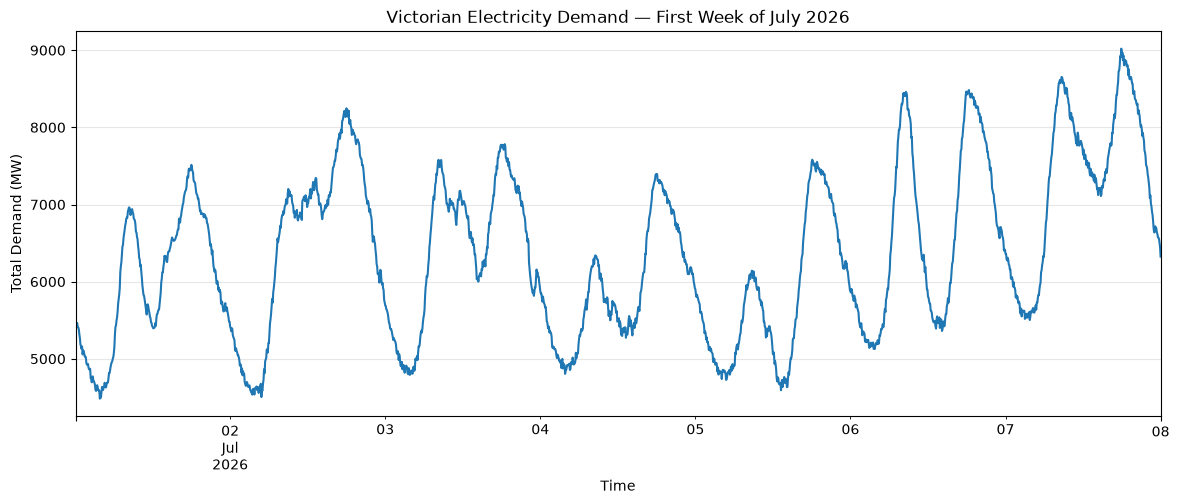

In [13]:
start = df["SETTLEMENTDATE"].min()

week = df[
    df["SETTLEMENTDATE"] < start + pd.Timedelta(days=7)
]

week.plot(
    x="SETTLEMENTDATE",
    y="TOTALDEMAND",
    figsize=(14, 5),
    legend=False,
)

plt.title("Victorian Electricity Demand — First Week of July 2026")
plt.xlabel("Time")
plt.ylabel("Total Demand (MW)")
plt.grid(alpha=0.3)
plt.show()

## Data quality and structure

The July 2026 Victorian dataset contains five-minute observations of total
electricity demand and regional reference price (RRP).

Initial checks examine:
- temporal coverage and frequency;
- missing and duplicate observations;
- demand and price distributions; and
- recurring patterns in electricity demand.

In [14]:
expected_intervals = 31 * 24 * 12

print(f"Expected observations: {expected_intervals:,}")
print(f"Actual observations:   {len(df):,}")
print(f"Missing values:         {df.isna().sum().sum()}")
print(f"Duplicate timestamps:   {df['SETTLEMENTDATE'].duplicated().sum()}")

assert len(df) == expected_intervals
assert df.isna().sum().sum() == 0
assert df["SETTLEMENTDATE"].duplicated().sum() == 0

Expected observations: 8,928
Actual observations:   8,928
Missing values:         0
Duplicate timestamps:   0


In [15]:
df["date"] = df["SETTLEMENTDATE"].dt.date
df["hour"] = df["SETTLEMENTDATE"].dt.hour
df["minute"] = df["SETTLEMENTDATE"].dt.minute
df["day_of_week"] = df["SETTLEMENTDATE"].dt.day_name()
df["day_number"] = df["SETTLEMENTDATE"].dt.dayofweek
df["is_weekend"] = df["day_number"] >= 5

df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE,date,hour,minute,day_of_week,day_number,is_weekend
0,VIC1,2026-07-01 00:05:00,5467.33,8.92,TRADE,2026-07-01,0,5,Wednesday,2,False
1,VIC1,2026-07-01 00:10:00,5469.00,10.48,TRADE,2026-07-01,0,10,Wednesday,2,False
2,VIC1,2026-07-01 00:15:00,5456.64,24.63,TRADE,2026-07-01,0,15,Wednesday,2,False
3,VIC1,2026-07-01 00:20:00,5462.64,20.61,TRADE,2026-07-01,0,20,Wednesday,2,False
4,VIC1,2026-07-01 00:25:00,5409.90,9.71,TRADE,2026-07-01,0,25,Wednesday,2,False


In [16]:
daily_summary = (
    df.groupby(["date", "day_of_week"], as_index=False)
    .agg(
        mean_demand=("TOTALDEMAND", "mean"),
        min_demand=("TOTALDEMAND", "min"),
        peak_demand=("TOTALDEMAND", "max"),
    )
)

daily_summary.head(10)

,date,day_of_week,mean_demand,min_demand,peak_demand
0,2026-07-01,Wednesday,5991.706063,4483.44,7514.09
1,2026-07-02,Thursday,6506.479132,4503.92,8246.49
2,2026-07-03,Friday,6419.696042,4793.14,7782.30
3,2026-07-04,Saturday,5914.884653,4804.98,7394.15
4,2026-07-05,Sunday,5807.200035,4592.77,7580.73
5,2026-07-06,Monday,6652.557674,5126.85,8483.64
6,2026-07-07,Tuesday,7330.786076,5502.92,9020.14
7,2026-07-08,Wednesday,6821.807118,5394.85,8344.20
8,2026-07-09,Thursday,7105.061146,5547.35,8853.83
9,2026-07-10,Friday,6765.275347,5524.35,8600.85


In [17]:
daily_summary.sort_values("peak_demand", ascending=False).head()

,date,day_of_week,mean_demand,min_demand,peak_demand
6,2026-07-07,Tuesday,7330.786076,5502.92,9020.14
8,2026-07-09,Thursday,7105.061146,5547.35,8853.83
28,2026-07-29,Wednesday,6643.959271,4845.69,8700.91
9,2026-07-10,Friday,6765.275347,5524.35,8600.85
30,2026-07-31,Friday,6859.414549,5508.70,8556.77


In [18]:
daily_summary.sort_values("mean_demand").head()

,date,day_of_week,mean_demand,min_demand,peak_demand
25,2026-07-26,Sunday,5575.350625,4624.63,7237.16
24,2026-07-25,Saturday,5731.670799,4662.07,7110.06
4,2026-07-05,Sunday,5807.200035,4592.77,7580.73
18,2026-07-19,Sunday,5817.709896,4090.52,7832.64
3,2026-07-04,Saturday,5914.884653,4804.98,7394.15


In [19]:
df["minute_of_day"] = (
    df["SETTLEMENTDATE"].dt.hour * 60
    + df["SETTLEMENTDATE"].dt.minute
)

In [20]:
typical_day = (
    df.groupby(["minute_of_day", "is_weekend"], as_index=False)
    ["TOTALDEMAND"]
    .mean()
)

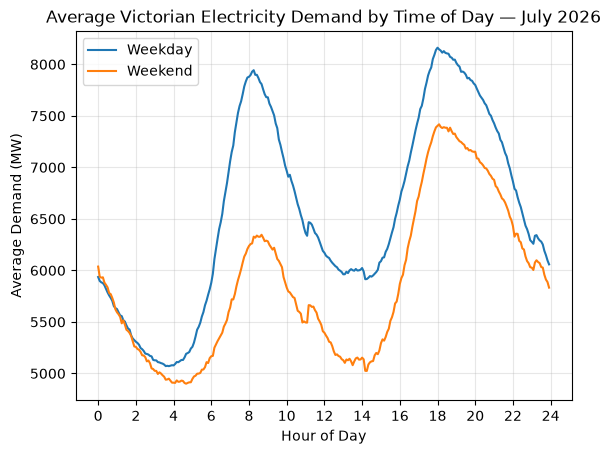

In [21]:
for weekend, group in typical_day.groupby("is_weekend"):
    label = "Weekend" if weekend else "Weekday"

    plt.plot(
        group["minute_of_day"] / 60,
        group["TOTALDEMAND"],
        label=label,
    )

plt.title("Average Victorian Electricity Demand by Time of Day — July 2026")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(0, 25, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Baseline forecasting

A useful forecasting model should outperform simple benchmarks.

The first benchmark assumes that electricity demand at a given time will be
the same as demand at the same time on the previous day.

Because observations occur every five minutes, one day corresponds to
288 observations.

In [22]:
df["forecast_1d"] = df["TOTALDEMAND"].shift(288)

In [23]:
df[
    ["SETTLEMENTDATE", "TOTALDEMAND", "forecast_1d"]
].iloc[285:295]

,SETTLEMENTDATE,TOTALDEMAND,forecast_1d
285,2026-07-01 23:50:00,5483.16,NaN
286,2026-07-01 23:55:00,5480.45,NaN
287,2026-07-02 00:00:00,5416.69,NaN
288,2026-07-02 00:05:00,5395.55,5467.33
289,2026-07-02 00:10:00,5356.94,5469.00
290,2026-07-02 00:15:00,5397.71,5456.64
291,2026-07-02 00:20:00,5386.68,5462.64
292,2026-07-02 00:25:00,5304.16,5409.90
293,2026-07-02 00:30:00,5280.55,5405.47
294,2026-07-02 00:35:00,5263.56,5379.33


In [24]:
baseline_1d = df.dropna(subset=["forecast_1d"]).copy()

baseline_1d[
    ["SETTLEMENTDATE", "TOTALDEMAND", "forecast_1d"]
].head()

,SETTLEMENTDATE,TOTALDEMAND,forecast_1d
288,2026-07-02 00:05:00,5395.55,5467.33
289,2026-07-02 00:10:00,5356.94,5469.00
290,2026-07-02 00:15:00,5397.71,5456.64
291,2026-07-02 00:20:00,5386.68,5462.64
292,2026-07-02 00:25:00,5304.16,5409.90


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_1d = mean_absolute_error(
    baseline_1d["TOTALDEMAND"],
    baseline_1d["forecast_1d"],
)

rmse_1d = np.sqrt(
    mean_squared_error(
        baseline_1d["TOTALDEMAND"],
        baseline_1d["forecast_1d"],
    )
)

print(f"1-day baseline MAE:  {mae_1d:.1f} MW")
print(f"1-day baseline RMSE: {rmse_1d:.1f} MW")

1-day baseline MAE:  430.2 MW
1-day baseline RMSE: 615.6 MW


In [28]:
df["forecast_7d"] = df["TOTALDEMAND"].shift(2016)

In [29]:
comparison = df.dropna(
    subset=["forecast_1d", "forecast_7d"]
).copy()

mae_1d = mean_absolute_error(
    comparison["TOTALDEMAND"],
    comparison["forecast_1d"],
)

mae_7d = mean_absolute_error(
    comparison["TOTALDEMAND"],
    comparison["forecast_7d"],
)

rmse_1d = np.sqrt(
    mean_squared_error(
        comparison["TOTALDEMAND"],
        comparison["forecast_1d"],
    )
)

rmse_7d = np.sqrt(
    mean_squared_error(
        comparison["TOTALDEMAND"],
        comparison["forecast_7d"],
    )
)

print(f"Yesterday baseline   — MAE: {mae_1d:.1f} MW | RMSE: {rmse_1d:.1f} MW")
print(f"Last-week baseline   — MAE: {mae_7d:.1f} MW | RMSE: {rmse_7d:.1f} MW")

Yesterday baseline   — MAE: 402.8 MW | RMSE: 581.8 MW
Last-week baseline   — MAE: 524.9 MW | RMSE: 672.7 MW


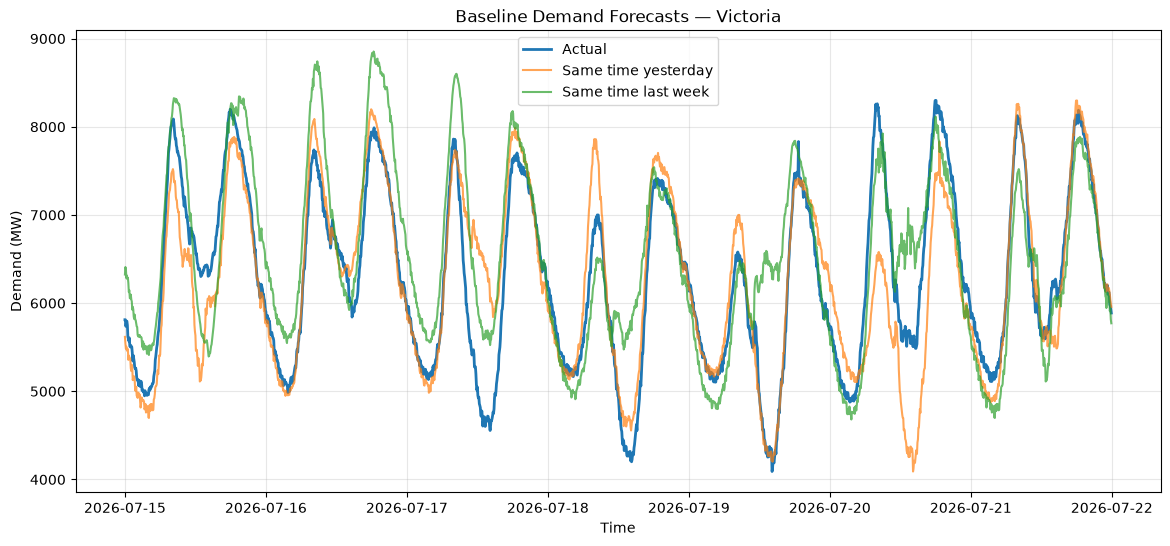

In [30]:
plot_start = pd.Timestamp("2026-07-15")
plot_end = plot_start + pd.Timedelta(days=7)

plot_data = comparison[
    (comparison["SETTLEMENTDATE"] >= plot_start)
    & (comparison["SETTLEMENTDATE"] < plot_end)
]

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["SETTLEMENTDATE"],
    plot_data["TOTALDEMAND"],
    label="Actual",
    linewidth=2,
)

plt.plot(
    plot_data["SETTLEMENTDATE"],
    plot_data["forecast_1d"],
    label="Same time yesterday",
    alpha=0.7,
)

plt.plot(
    plot_data["SETTLEMENTDATE"],
    plot_data["forecast_7d"],
    label="Same time last week",
    alpha=0.7,
)

plt.title("Baseline Demand Forecasts — Victoria")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [31]:
comparison = df.dropna(
    subset=["forecast_1d", "forecast_7d"]
).copy()

mae_1d = mean_absolute_error(
    comparison["TOTALDEMAND"],
    comparison["forecast_1d"],
)

mae_7d = mean_absolute_error(
    comparison["TOTALDEMAND"],
    comparison["forecast_7d"],
)

rmse_1d = np.sqrt(
    mean_squared_error(
        comparison["TOTALDEMAND"],
        comparison["forecast_1d"],
    )
)

rmse_7d = np.sqrt(
    mean_squared_error(
        comparison["TOTALDEMAND"],
        comparison["forecast_7d"],
    )
)

print(f"Yesterday baseline — MAE: {mae_1d:.1f} MW | RMSE: {rmse_1d:.1f} MW")
print(f"Last-week baseline — MAE: {mae_7d:.1f} MW | RMSE: {rmse_7d:.1f} MW")

Yesterday baseline — MAE: 402.8 MW | RMSE: 581.8 MW
Last-week baseline — MAE: 524.9 MW | RMSE: 672.7 MW


In [32]:
comparison["error_1d"] = abs(
    comparison["TOTALDEMAND"] - comparison["forecast_1d"]
)

comparison["error_7d"] = abs(
    comparison["TOTALDEMAND"] - comparison["forecast_7d"]
)

In [33]:
error_by_day = (
    comparison.groupby("day_of_week")
    .agg(
        yesterday_mae=("error_1d", "mean"),
        last_week_mae=("error_7d", "mean"),
    )
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

error_by_day.loc[day_order]

,yesterday_mae,last_week_mae
day_of_week,,
Monday,638.982697,405.462801
Tuesday,265.780498,630.906100
Wednesday,440.284031,564.816195
Thursday,245.496372,587.916875
Friday,389.897170,577.228255
Saturday,661.964694,376.003168
Sunday,220.952627,480.420266


In [34]:
comparison[
    [
        "SETTLEMENTDATE",
        "TOTALDEMAND",
        "forecast_1d",
        "error_1d",
        "forecast_7d",
        "error_7d",
    ]
].head()

,SETTLEMENTDATE,TOTALDEMAND,forecast_1d,error_1d,forecast_7d,error_7d
2016,2026-07-08 00:05:00,6408.93,6357.21,51.72,5467.33,941.60
2017,2026-07-08 00:10:00,6381.60,6288.17,93.43,5469.00,912.60
2018,2026-07-08 00:15:00,6282.52,6275.53,6.99,5456.64,825.88
2019,2026-07-08 00:20:00,6312.64,6310.11,2.53,5462.64,850.00
2020,2026-07-08 00:25:00,6274.24,6284.25,10.01,5409.90,864.34


### Baseline results

The previous-day benchmark substantially outperformed the previous-week
benchmark overall, achieving an MAE of 402.8 MW compared with 524.9 MW.

However, forecast performance varied strongly by day of week. The
previous-day forecast performed particularly poorly on Mondays and
Saturdays, when it uses Sunday and Friday respectively as the comparison
day. On these transition days, the previous-week benchmark performed
considerably better.

This suggests that electricity demand exhibits both strong short-term
autocorrelation and systematic calendar effects. A more sophisticated
forecasting model should therefore combine recent demand with information
about time of day and day of week.